In [117]:
%matplotlib notebook

import numpy as np
from numpy.fft import fft2, ifft2
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.signal import convolve2d as conv2d


In [58]:
a = np.random.random_integers(2,size=(4,4))-1
b = np.random.random_integers(2,size=(3,3))-1


conv2d(a,b, mode = "same", boundary="wrap")

/tmp/ipykernel_1832/1660622840.py:1: DeprecationWarning: This function is deprecated. Please call randint(1, 2 + 1) instead
  a = np.random.random_integers(2,size=(4,4))-1
/tmp/ipykernel_1832/1660622840.py:2: DeprecationWarning: This function is deprecated. Please call randint(1, 2 + 1) instead
  b = np.random.random_integers(2,size=(3,3))-1


array([[0, 2, 1, 3],
       [1, 1, 1, 1],
       [2, 2, 1, 2],
       [1, 2, 2, 2]])

In [67]:
conwayog = np.array([[1,1,1],
                      [1,0,1],
                      [1,1,1]])

def conway_update(state, neighbors):
    if neighbors < 2 or neighbors > 3:
        state = 0
    elif neighbors == 3:
        state = 1
    return state

conway_updatev = np.vectorize(conway_update)

def fft_convolve2d(x,y):
    """ 2D convolution, using FFT"""
    fr = fft2(x)
    fr2 = fft2(np.flipud(np.fliplr(y)))
    m,n = fr.shape
    cc = np.real(ifft2(fr*fr2))
    cc = np.roll(cc, -m/2+1,axis=0)
    cc = np.roll(cc, -n/2+1,axis=1)
    return cc

# Define update rules for the game of life
def life_run(grid_init, num_frames):

    grid_history = np.zeros((num_frames, *grid_init.shape))
    grid_history[0,:,:] = grid_init

    for f in range(1,num_frames):
        grid_history[f,:,:] = conway_updatev(grid_history[f-1,:,:], conv2d(grid_history[f-1,:,:], conwayog,mode = "same", boundary="wrap"))

    return grid_history


In [113]:
k4grid = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
                   [0, 0, 1, 0, 1, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]) 

glider = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]) 

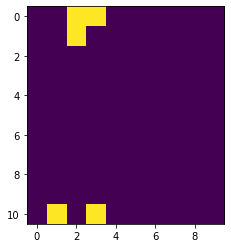

In [112]:
# Set up the size of the grid
M = 10  # 50x50 grid
N = 10
# Random initial state (0 = dead, 1 = alive)
# grid = np.random.choice([0, 1], size=(M, N))

grid = glider

grid_history = life_run(grid, 100)

# Set up the plot
fig, ax = plt.subplots()
img = ax.imshow(grid_history[80], interpolation='nearest')
plt.show()

In [120]:
ax = plt.figure().add_subplot(projection='3d')
ax.voxels(grid_history, facecolors="red", edgecolor='k')

# plt.show()

<IPython.core.display.Javascript object>

{(0, 1, 1): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f248b640>,
 (0, 1, 3): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f47187c0>,
 (0, 2, 2): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f44e8580>,
 (0, 2, 3): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f44e88b0>,
 (0, 3, 2): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f44e82b0>,
 (1, 1, 3): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f47c2310>,
 (1, 2, 1): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f47c28b0>,
 (1, 2, 3): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f47c2790>,
 (1, 3, 2): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f47c2a60>,
 (1, 3, 3): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f4641520>,
 (2, 1, 2): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f4641850>,
 (2, 2, 3): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f23d4fa0>,
 (2, 2, 4): <mpl_toolkits.mplot3d.art3d.Poly3DCollection at 0x7ff5f23d4eb0>,